In [10]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns



def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, sep=r'\s+') # Use raw string for regex separator
    return dataframe.values

# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y


# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
    # load all train
    trainX, trainy = load_dataset_group('train', prefix + '/') # Remove extra 'UCI HAR Dataset/'
    # load all test
    testX, testy = load_dataset_group('test', prefix + '/') # Remove extra 'UCI HAR Dataset/'

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1
    #one hot encode y
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print(trainX.shape, trainy.shape, trainy_one_hot.shape, testX.shape, testy.shape, testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot

trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset('/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset')

from sklearn.model_selection import train_test_split

X_train,X_val,y_train_one_hot,y_val_one_hot,y_train,y_val=train_test_split(trainX, trainy_one_hot, trainy,test_size=0.2,random_state=100)

X_train.shape,X_val.shape,y_train_one_hot.shape,y_val_one_hot.shape,y_train.shape,y_val.shape

(7352, 128, 9) (7352, 1) (7352, 6) (2947, 128, 9) (2947, 1) (2947, 6)


((5881, 128, 9), (1471, 128, 9), (5881, 6), (1471, 6), (5881, 1), (1471, 1))

In [11]:
n_timesteps, n_features, n_outputs = X_train.shape[1], X_train.shape[2], y_train_one_hot.shape[1]

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --- 기존 코드에서 정의된 변수 사용 (UCI HAR 데이터셋 기준) ---
n_timesteps = 128
n_features = 9
n_outputs = 6
# ------------------------------------

def build_lstm_model(n_timesteps, n_features, n_outputs):
    """
    단일 LSTM 층을 사용하는 시퀀셜 모델을 정의합니다.
    """
    model = Sequential()

    # 1. LSTM 층
    # units=100, return_sequences=False (마지막 시점 출력만 사용)
    model.add(LSTM(units=100,
                   input_shape=(n_timesteps, n_features),
                   return_sequences=False))

    # 2. 드롭아웃
    model.add(Dropout(0.5))

    # 3. 출력(분류) 층
    model.add(Dense(n_outputs, activation='softmax'))

    return model

# 1. LSTM 모델 생성
lstm_model = build_lstm_model(n_timesteps, n_features, n_outputs)

# 2. 모델 컴파일 (요청하신 부분)
# 다중 클래스 분류에 적합한 loss와 optimizer, metrics 설정
lstm_model.compile(loss='categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

# 3. 모델 구조 요약 (요청하신 부분)
print("\n--- LSTM Model Summary ---")
lstm_model.summary()

# 4. 모델 훈련 (이후 훈련 코드와 연결하여 실행하시면 됩니다.)
# history = lstm_model.fit(...)


--- LSTM Model Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        44,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,606 (174.24 KB)

 Trainable params: 44,606 (174.24 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model_history=lstm_model.fit(x=X_train, y=y_train_one_hot, epochs=30, batch_size=32,validation_split=0.1)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3549 - loss: 1.4939 - val_accuracy: 0.6367 - val_loss: 0.8761
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5607 - loss: 1.0171 - val_accuracy: 0.5823 - val_loss: 0.9017
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6041 - loss: 0.9144 - val_accuracy: 0.7250 - val_loss: 0.7658
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6876 - loss: 0.7825 - val_accuracy: 0.7946 - val_loss: 0.5351
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7688 - loss: 0.5671 - val_accuracy: 0.8285 - val_loss: 0.4770
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7992 - loss: 0.6092 - val_accuracy: 0.7946 - val_loss: 0.5292
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8229 - loss: 0.4787 - val_accuracy: 0.9168 - val_loss: 0.2450
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8908 - loss: 0.3261 - val_accuracy:

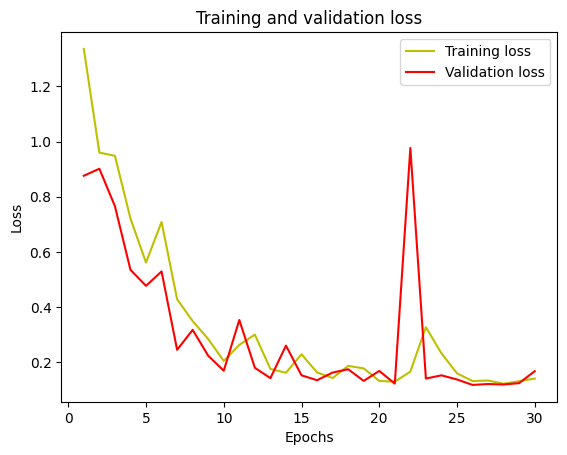

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =model_history.history['loss']
val_loss =model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

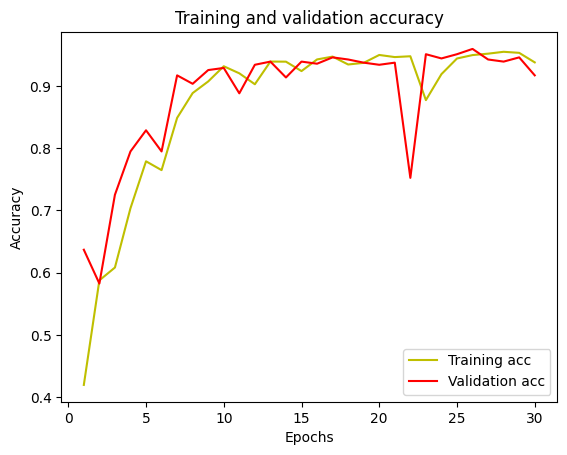

In [18]:
acc =model_history.history['accuracy']
val_acc =model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

23/93 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_7
Received: inputs=('Tensor(shape=(32, 128, 9))', 'Tensor(shape=(32, 128, 9))', 'Tensor(shape=(32, 128, 9))', 'Tensor(shape=(32, 128, 9))')
  warnings.warn(msg)


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_7
Received: inputs=('Tensor(shape=(None, 128, 9))', 'Tensor(shape=(None, 128, 9))', 'Tensor(shape=(None, 128, 9))', 'Tensor(shape=(None, 128, 9))')
  warnings.warn(msg)


[[475   1  20   0   0   0]
 [  8 455   8   0   0   0]
 [  1   6 413   0   0   0]
 [  1   2   2 183 303   0]
 [  0   1   0  17 514   0]
 [  0   0   0   0   0 537]]
0.8744485917882593
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       496
           1       0.98      0.97      0.97       471
           2       0.93      0.98      0.96       420
           3       0.92      0.37      0.53       491
           4       0.63      0.97      0.76       532
           5       1.00      1.00      1.00       537

    accuracy                           0.87      2947
   macro avg       0.91      0.87      0.86      2947
weighted avg       0.90      0.87      0.86      2947



<Axes: >

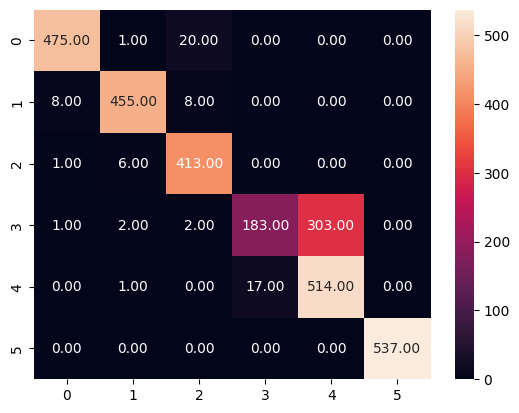

In [20]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
pred=lstm_model.predict([testX,testX,testX,testX])
pred=np.argmax(pred, axis=-1)
cm=confusion_matrix(testy,pred)
print(cm)
print(accuracy_score(testy,pred))
print(classification_report(testy,pred))
sns.heatmap(cm, annot=True, fmt = '.2f')